In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/10010
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  351.11374968749476
RUN  2 , total integrated cost =  163.20502909200277
RUN  3 , total integrated cost =  153.10290930523524
RUN  4 , total integrated cost =  146.20760704846393
RUN  5 , total integrated cost =  135.17182383667577
RUN  6 , total integrated cost =  130.7148263258477
RUN  7 , total integrated cost =  127.38015033082237
RUN  8 , total integrated cost =  127.13534469210873
RUN  9 , total integrated cost =  126.57851951436788
RUN  10 , total integrated cost =  126.46411749441423
RUN  11 , total integrated cost =  126.0267484943902
RUN  12 , total integrated cost =  125.41860726882383
RUN  13 , total integrated cost =  125.37231573964044
RUN  14 , total integrated cost =  125.30560427952585
RUN  15 , total integrated cost =  124.97953614708794


ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  124.1382151007651
Control only changes marginally.
RUN  44 , total integrated cost =  124.13821509390053
Improved over  44  iterations in  12.52975825406611  seconds by  97.89682029642393  percent.
Problem in initial value trasfer:  Vmean_exc -65.53459246538375 -65.541439693332
weight =  475.470545051231
set cost params:  1.0 0.0 475.470545051231
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5787.655052935608
Gradient descend method:  None
RUN  1 , total integrated cost =  5440.302739859738
RUN  2 , total integrated cost =  5439.932945569405
RUN  3 , total integrated cost =  5423.217011221123


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  5423.217011221117
RUN  5 , total integrated cost =  5423.217011221117
Control only changes marginally.
RUN  5 , total integrated cost =  5423.217011221117
Improved over  5  iterations in  0.18179978802800179  seconds by  6.296816903931429  percent.
Problem in initial value trasfer:  Vmean_exc -59.71839453594531 -59.742429112024084
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  1 , total integrated cost =  9213.406283465663
RUN  2 , total integrated cost =  9176.525091905307
RUN  3 , total integrated cost =  9176.457808000228
RUN  4 , total integrated cost =  9176.447431548073
RUN  5 , total integrated cost =  9176.438831620857
RUN  6 , total integrated cost =  9176.42932719908
RUN  7 , total integrated cost =  9176.422695416104
RUN  8 , total integrated cost =  9176.41421459485
RUN  9 , total i

...

Control only changes marginally.
RUN  99 , total integrated cost =  17896.526539304406
Improved over  99  iterations in  2.070920066908002  seconds by  5.817562607253592  percent.
Problem in initial value trasfer:  Vmean_exc -56.689089146096535 -56.689197744754274
weight =  10.617690810335901
set cost params:  1.0 0.0 10.617690810335901
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17904.13703734515
Gradient descend method:  None
RUN  1 , total integrated cost =  17904.13703734515
Control only changes marginally.
RUN  1 , total integrated cost =  17904.13703734515
Improved over  1  iterations in  0.06997806951403618  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.689089146096535 -56.689197744754274
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14446.643021512598
Gradient descend method:  None
RUN  1 , total integrated cost = 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  27 , total integrated cost =  13472.794832671747
Improved over  27  iterations in  0.6152229402214289  seconds by  6.740999880669079  percent.
Problem in initial value trasfer:  Vmean_exc -56.67143324259603 -56.67158009443238
weight =  10.722825665302388
set cost params:  1.0 0.0 10.722825665302388
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13482.999406639266
Gradient descend method:  None
RUN  1 , total integrated cost =  13482.999406639266
Control only changes marginally.
RUN  1 , total integrated cost =  13482.999406639266
Improved over  1  iterations in  0.07086376287043095  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67143324259603 -56.67158009443238
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10019.968518582271
Gradient descend method:  None
RUN  1 , total integrated cost =  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  9086.737319933833
Control only changes marginally.
RUN  103 , total integrated cost =  9086.737319609845
Improved over  103  iterations in  2.1773543525487185  seconds by  9.313713882850294  percent.
Problem in initial value trasfer:  Vmean_exc -56.64441300059867 -56.64458968158296
weight =  11.027025615628224
set cost params:  1.0 0.0 11.027025615628224
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9098.653897298605
Gradient descend method:  None
RUN  1 , total integrated cost =  9098.653897298605
Control only changes marginally.
RUN  1 , total integrated cost =  9098.653897298605
Improved over  1  iterations in  0.06912484765052795  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64441300059867 -56.64458968158296


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


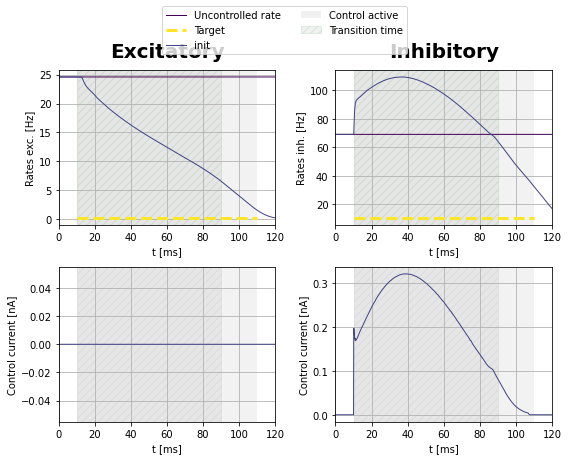

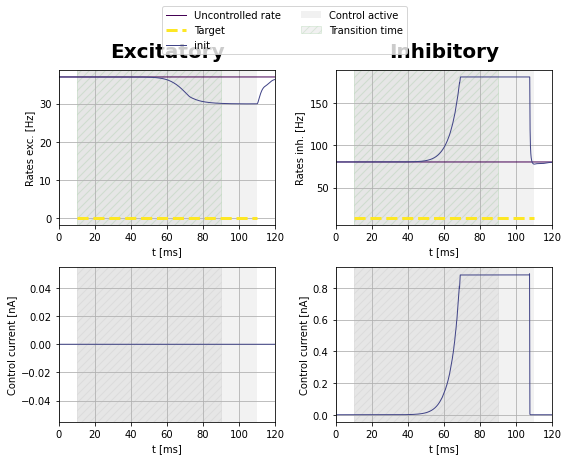

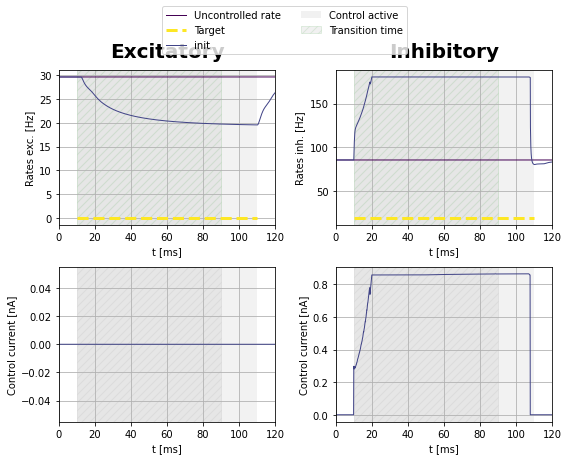

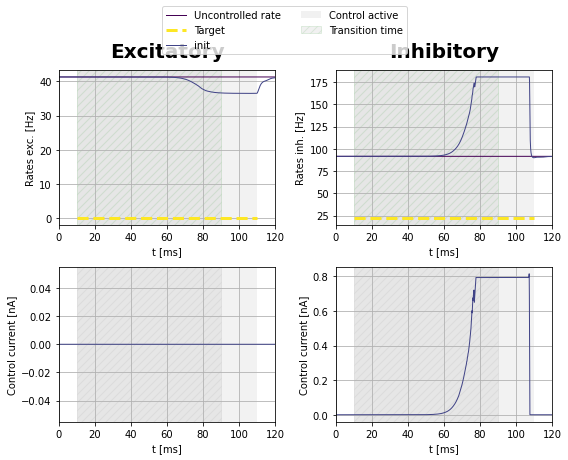

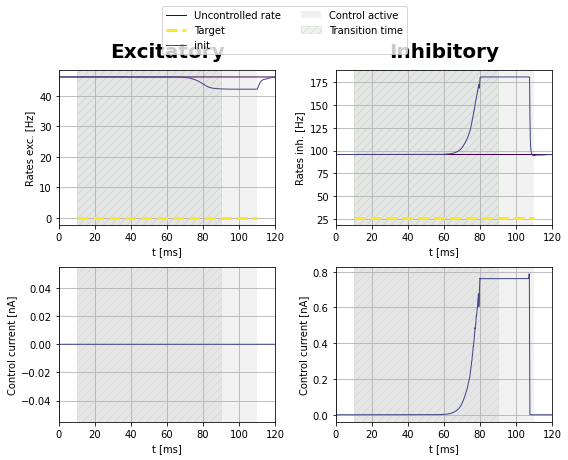

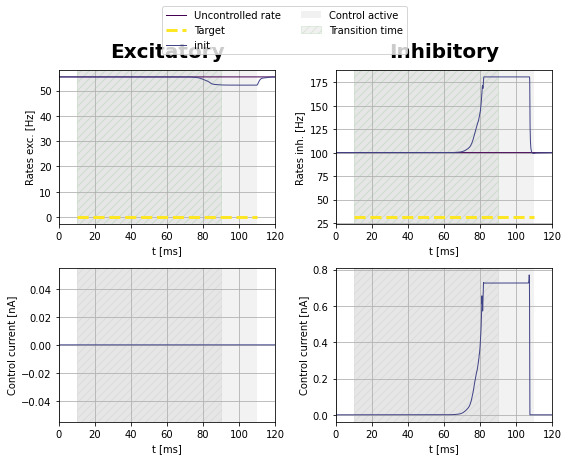

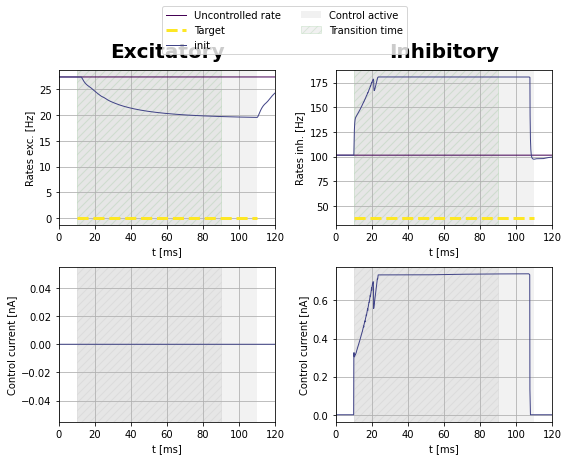

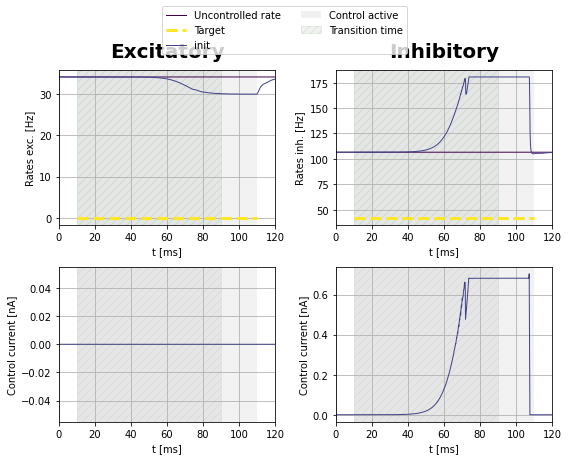

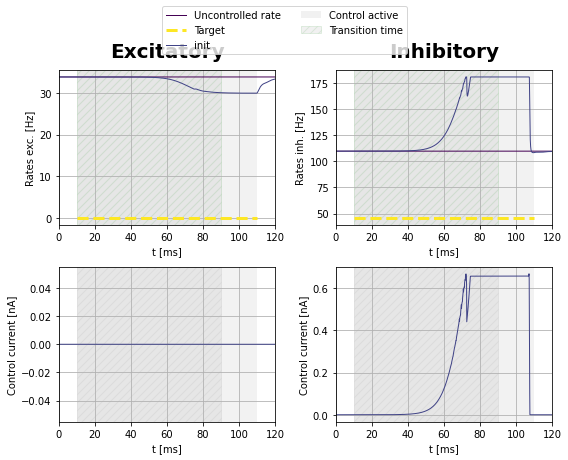

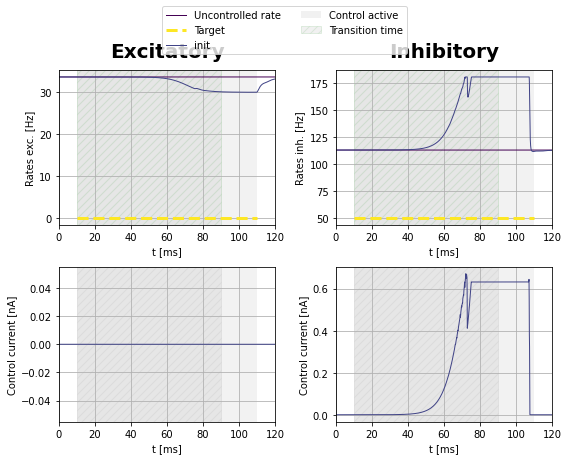

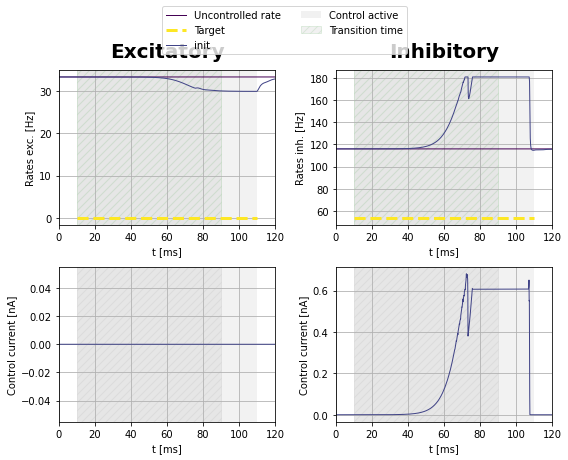

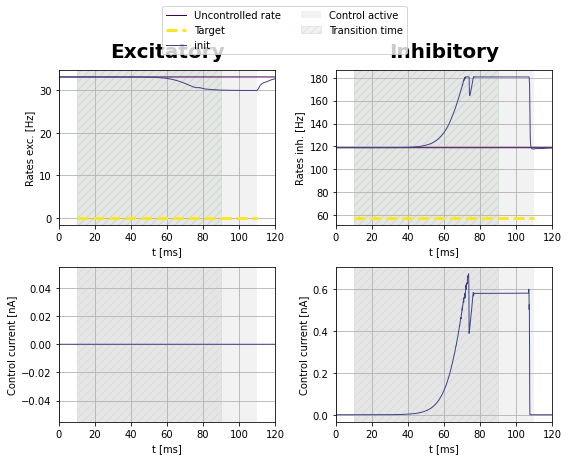

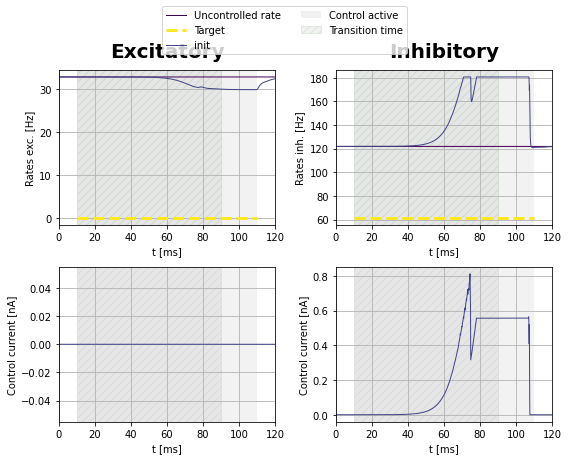

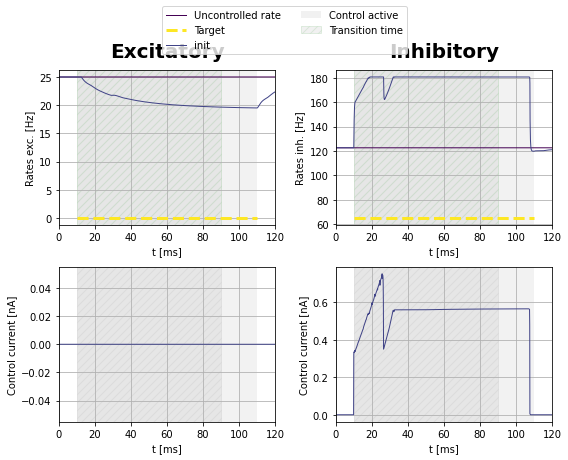

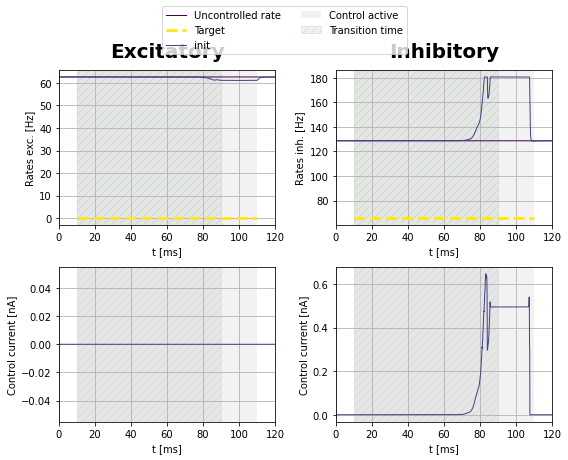

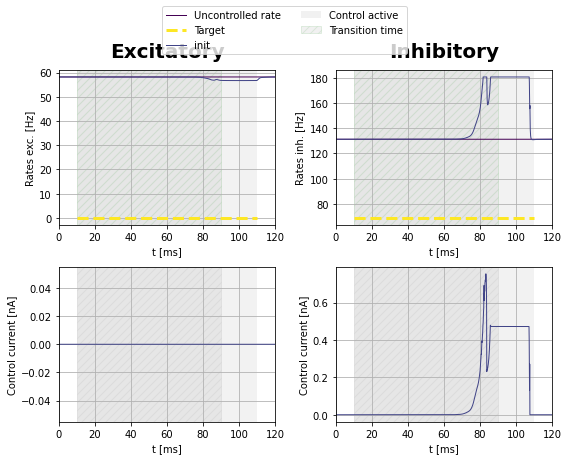

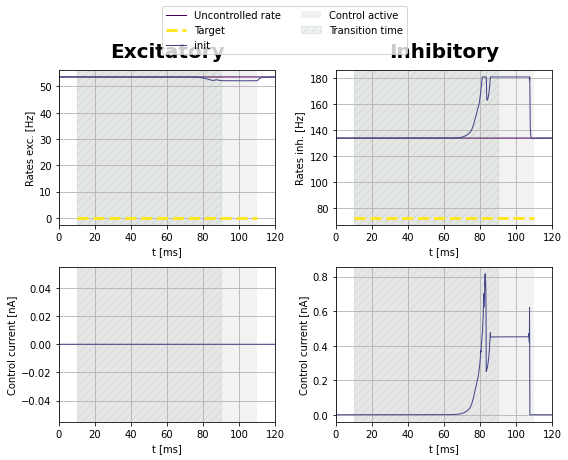

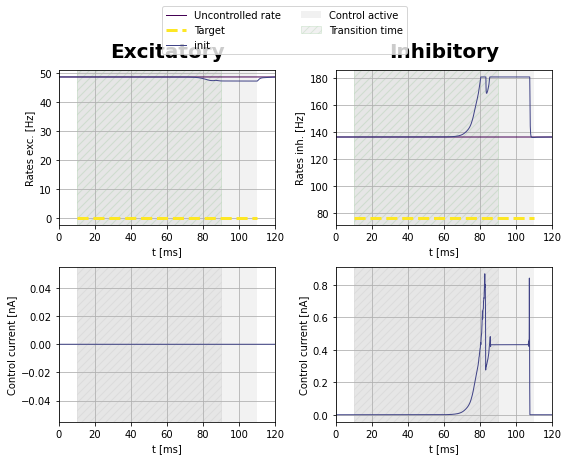

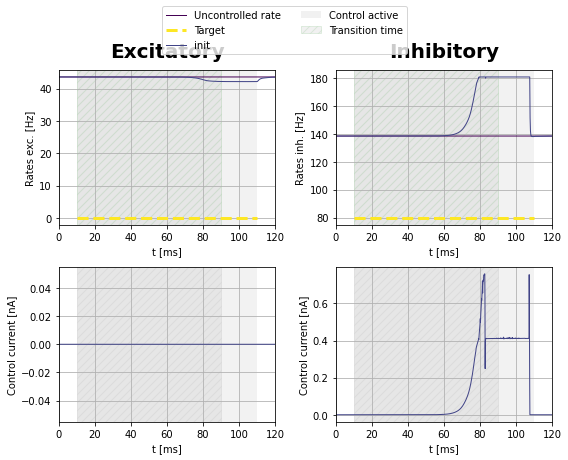

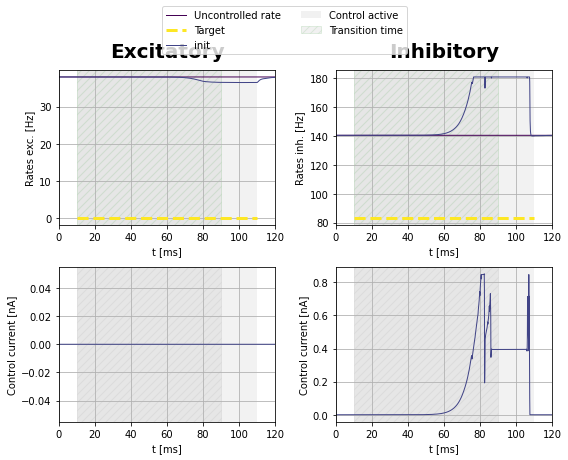

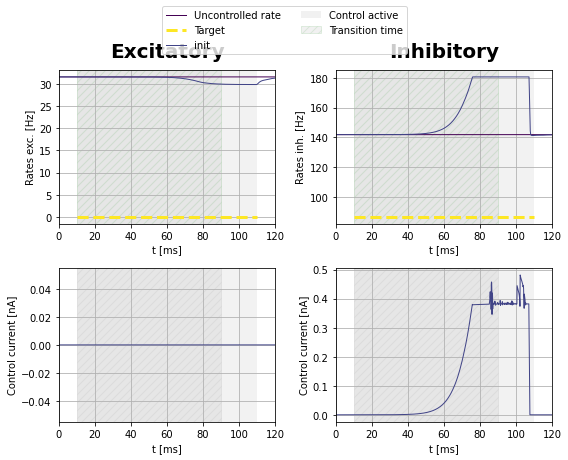

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  9185.678777892894
Control only changes marginally.
RUN  42 , total integrated cost =  9185.678777892892
Improved over  42  iterations in  0.8843689113855362  seconds by  29.1511925106921  percent.
Problem in initial value trasfer:  Vmean_exc -56.64475974101231 -56.64523819065448
weight =  14.759067279338318
set cost params:  1.0 0.0 14.759067279338318
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9310.297607353703
Gradient descend method:  None
RUN  1 , total integrated cost =  9310.297607353703
Control only changes marginally.
RUN  1 , total integrated cost =  9310.297607353703
Improved over  1  iterations in  0.06843871995806694  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64475974101231 -56.64523819065448
-------  14 0.4250000000000001 0.4500000000000002
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  550 , total integrated cost =  4339.84024059496
Improved over  550  iterations in  11.002083022147417  seconds by  46.56450549122195  percent.
Problem in initial value trasfer:  Vmean_exc -56.62784764320218 -56.62781784969383
weight =  20.268431723403314
set cost params:  1.0 0.0 20.268431723403314
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4692.46288917719
Gradient descend method:  None
RUN  1 , total integrated cost =  4692.46288917719
Control only changes marginally.
RUN  1 , total integrated cost =  4692.46288917719
Improved over  1  iterations in  0.07043404132127762  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62784764320218 -56.62781784969383
-------  21 0.47500000000000014 0.4750000000000002
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16664.150130763737
Gradient descend method: 

...

RUN  1 , total integrated cost =  13464.99665346799
Control only changes marginally.
RUN  1 , total integrated cost =  13464.99665346799
Improved over  1  iterations in  0.06959930434823036  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67155676810384 -56.671724617739855
-------  140 0.4500000000000001 0.9000000000000006
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9902.302271009565
Gradient descend method:  None
RUN  1 , total integrated cost =  9174.664925042434
RUN  2 , total integrated cost =  9136.04906344513
RUN  3 , total integrated cost =  9123.714646247478
RUN  4 , total integrated cost =  9116.57254443012
RUN  5 , total integrated cost =  9112.575963308036
RUN  6 , total integrated cost =  9110.354644026089
RUN  7 , total integrated cost =  9108.783624325904
RUN  8 , total integrated cost =  9107.974261632924
RUN  9 , total integrated cost =  91

ERROR:root:Problem in initial value trasfer


RUN  160 , total integrated cost =  9091.822898800656
Control only changes marginally.
RUN  165 , total integrated cost =  9091.818904294929
Improved over  165  iterations in  3.373139029368758  seconds by  8.18479727777492  percent.
Problem in initial value trasfer:  Vmean_exc -56.644321001050564 -56.64449390910724
weight =  11.020862408344813
set cost params:  1.0 0.0 11.020862408344813
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9105.205406886767
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  9105.205406886766
RUN  2 , total integrated cost =  9105.205406886766
Control only changes marginally.
RUN  2 , total integrated cost =  9105.205406886766
Improved over  2  iterations in  0.12163608521223068  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.644321001050564 -56.64449390910724
------------------------------------------------------------
-------------------- 1
------------------------------------------------------------
found solution:  [0]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
closest index  -1
set cost params:  1.0 0.0 10.0
all options tried already
-------  14 0.4250000000000001 0.4500000000000002
closest index  -1
set cost params:  1.0 0.0 10.0
all options tried already
-------  21 0.47500000000000014 0.4750000000000002
closest index  -1
set cost params:  1.0 0.0 10.0
all options tried already
-------  28 0.5000000

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  516.4825975045179
set cost params:  1.0 0.0 516.4825975045179
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5877.096357600346
Gradient descend method:  None
RUN  1 , total integrated cost =  5876.95231045528
RUN  2 , total integrated cost =  5876.9519544581535
RUN  3 , total integrated cost =  5876.951953490466
RUN  4 , total integrated cost =  5876.951953481706
RUN  5 , total integrated cost =  5876.9519534811825
RUN  6 , total integrated cost =  5876.9519534811025
RUN  7 , total integrated cost =  5876.951953481092


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  5876.951953481092
Control only changes marginally.
RUN  8 , total integrated cost =  5876.951953481092
Improved over  8  iterations in  0.23764386028051376  seconds by  0.002457065708441064  percent.
Problem in initial value trasfer:  Vmean_exc -59.60267247898581 -59.626238995710686
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
no convergence
weight =  11.546004988306537
set cost params:  1.0 0.0 11.546004988306537
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  27289.288221528706
Gradient descend method:  None
RUN  1 , total integrated cost =  27289.288221528703
RUN  2 , total integrated cost =  27289.2882215287
RUN  3 , total integrated cost =  27289.28822

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  27289.288221528695
Control only changes marginally.
RUN  4 , total integrated cost =  27289.288221528695
Improved over  4  iterations in  0.1973332967609167  seconds by  4.263256414560601e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.70355632042643 -56.703631779837224
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
no convergence
weight =  13.625388544961172
set cost params:  1.0 0.0 13.625388544961172
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9235.517177053971
Gradient descend method:  None
RUN  1 , total integrated cost =  9235.517177053971
Control only changes marginally.
RUN  1 , total integrated cost =  9235.517177053971
Improved ov

...

RUN  2 , total integrated cost =  27389.988669457263
RUN  3 , total integrated cost =  27389.98866851523
RUN  4 , total integrated cost =  27389.988668390957
RUN  5 , total integrated cost =  27389.98866837883
RUN  6 , total integrated cost =  27389.988668378814
RUN  7 , total integrated cost =  27389.988668378814
Control only changes marginally.
RUN  7 , total integrated cost =  27389.988668378814
Improved over  7  iterations in  0.21724041551351547  seconds by  1.937378613092733e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.703556321327184 -56.70363178074872
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
------- 

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  27407.772195958434
Control only changes marginally.
RUN  41 , total integrated cost =  27407.772195958434
Improved over  41  iterations in  0.9331744946539402  seconds by  0.0003043181421844565  percent.
Problem in initial value trasfer:  Vmean_exc -56.70355638756473 -56.70363186001907
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
converged for  98
-------  105 0.5750000000000002 0.7750000000000005
converged for  

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  27427.448238290726
Control only changes marginally.
RUN  1 , total integrated cost =  27427.448238290726
Improved over  1  iterations in  0.07202156819403172  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70355638756473 -56.70363186001907
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
converged for  98
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  279.56880246300284
Gradient descend method:  None
RUN  1 , total integrated cost =  111.85502358124623
RUN  2 , total integrated cost =  109.14205876563837
RUN  3 , total integrated cost =  94.21011202549278
RUN  4 , total integrated cost =  24.687919593172097
RUN  5 , total integrated cost =  10.523889249662952
RUN  6 , total integrated cost =  10.049557807587558
RUN  7 , total integrated cost =  9.925780490866634
RUN  8 , total integrated cost =  9.444589177215061
RUN  9 , total integrated cost =  9.433329887280577
RUN  10 , total integrated cost =  9.433062001290608
RUN  11 , total integrated cost =  9.433042410747
RUN  12 , total integrated cost =  9.433041253842717
RUN  13 , total integrated cost =  9.433041131558015
RUN  14 , total integrated cost =  9.433041122744346
RUN  15 , total integrated cost =  9.433041121953739
RUN  16 , 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  23 , total integrated cost =  9.433041121918192
Improved over  23  iterations in  1.4967302363365889  seconds by  96.62586059717214  percent.
Problem in initial value trasfer:  Vmean_exc -64.28161489440569 -64.27260782772264
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  91.72955524602087
Gradient descend method:  HS
RUN  1 , total integrated cost =  91.16881928028222
RUN  2 , total integrated cost =  90.68894735357064
RUN  3 , total integrated cost =  90.67560809268431


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  90.67560809268431
Control only changes marginally.
RUN  4 , total integrated cost =  90.67560809268431
Improved over  4  iterations in  0.6184587813913822  seconds by  1.1489722701803657  percent.
Problem in initial value trasfer:  Vmean_exc -64.74577511704726 -64.73993600314517
weight =  6508.365201284587
set cost params:  1.0 0.0 6508.365201284587
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5855.611536358738
Gradient descend method:  None
RUN  1 , total integrated cost =  5733.7579388645245
RUN  2 , total integrated cost =  5733.5802660768895
RUN  3 , total integrated cost =  5733.579883711028
RUN  4 , total integrated cost =  5733.579882695894
RUN  5 , total integrated cost =  5733.579882689524
RUN  6 , total integrated cost =  5733.579882689499
RUN  7 , total integrated cost =  5733.579882689495


...

Control only changes marginally.
RUN  52 , total integrated cost =  16.842224348005345
Improved over  52  iterations in  4.5741378758102655  seconds by  99.81475407148673  percent.
Problem in initial value trasfer:  Vmean_exc -72.60396509319578 -72.64444863738453
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  166.85180726727097
Gradient descend method:  HS
RUN  1 , total integrated cost =  164.5929333712682
RUN  2 , total integrated cost =  163.34177028086714
RUN  3 , total integrated cost =  162.18334692565531
RUN  4 , total integrated cost =  161.66329342068425
RUN  5 , total integrated cost =  161.6632934206842


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  161.6632934206842
Control only changes marginally.
RUN  6 , total integrated cost =  161.6632934206842
Improved over  6  iterations in  0.9119730219244957  seconds by  3.1096539687314078  percent.
Problem in initial value trasfer:  Vmean_exc -71.12326752072335 -71.1707023971364
weight =  6197.047996280802
set cost params:  1.0 0.0 6197.047996280802
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9939.619036449883
Gradient descend method:  None
RUN  1 , total integrated cost =  9693.558308298045


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  9693.558308298036
RUN  3 , total integrated cost =  9693.558308298036
Control only changes marginally.
RUN  3 , total integrated cost =  9693.558308298036
Improved over  3  iterations in  0.5386484432965517  seconds by  2.4755549206615655  percent.
Problem in initial value trasfer:  Vmean_exc -62.3783934504405 -62.43123435561544


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


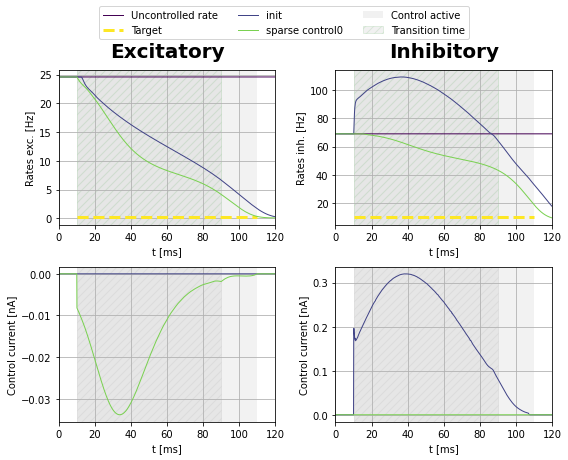

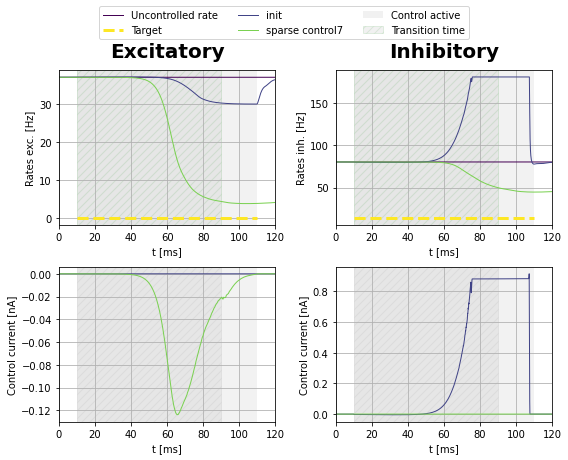

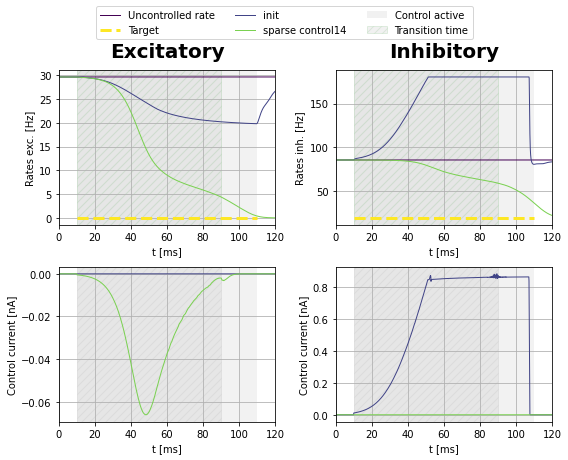

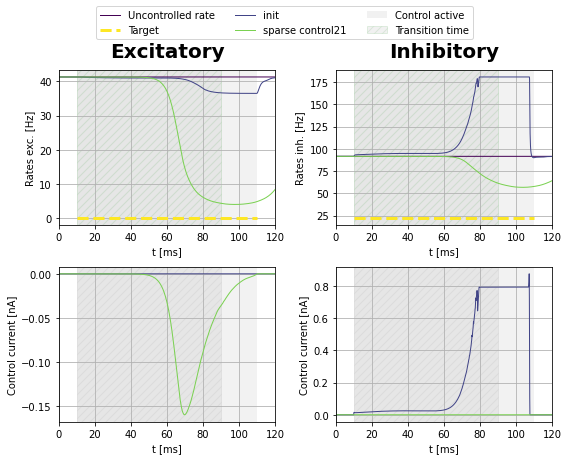

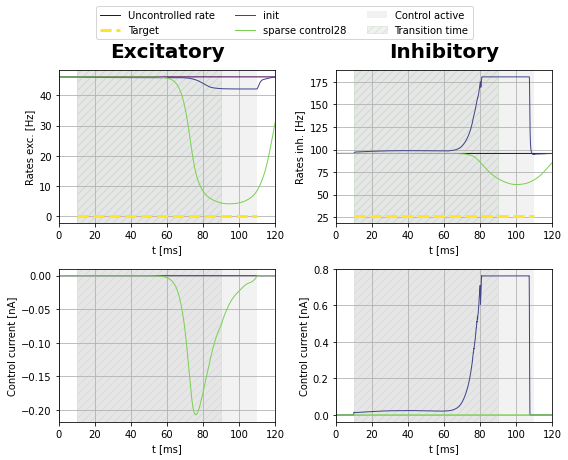

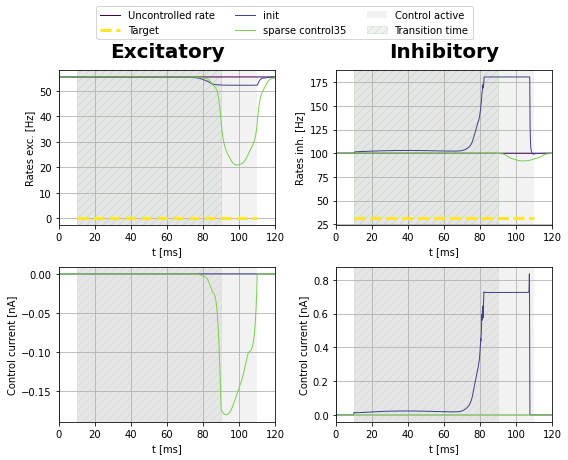

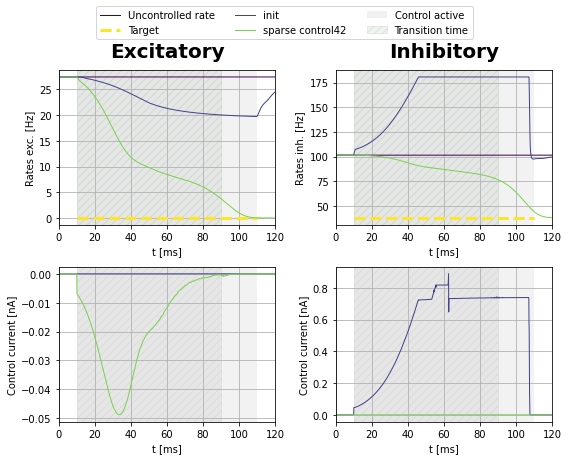

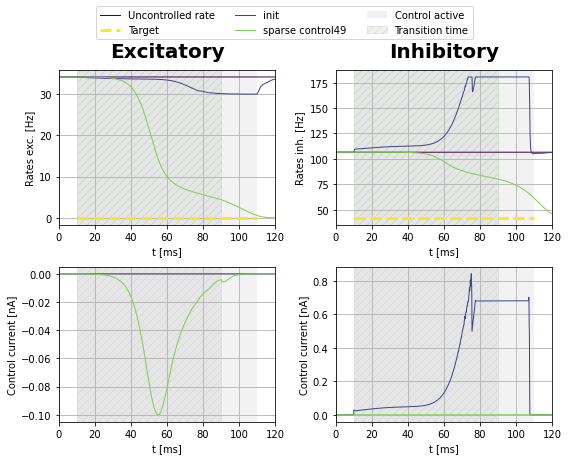

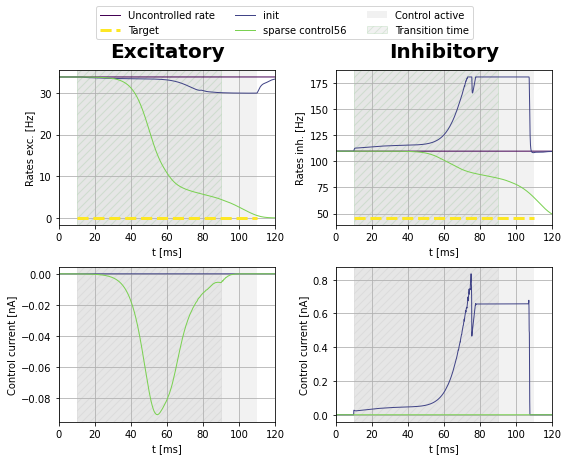

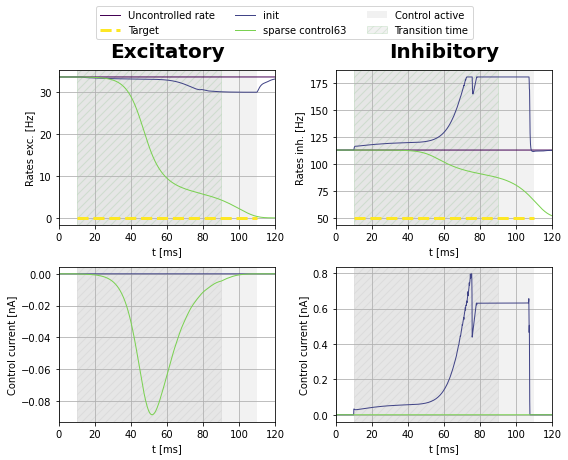

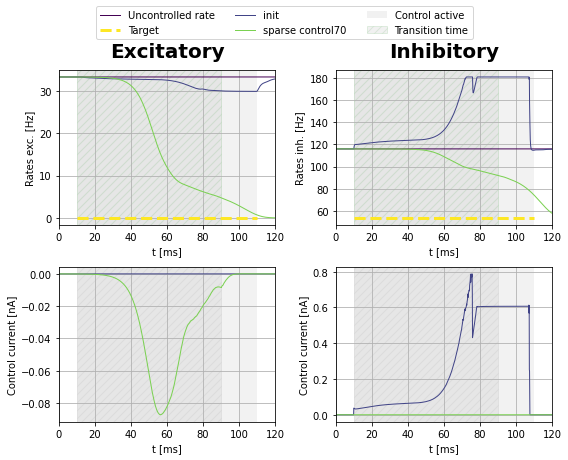

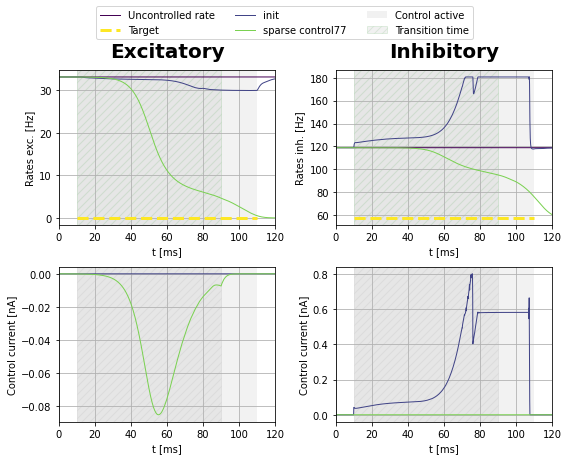

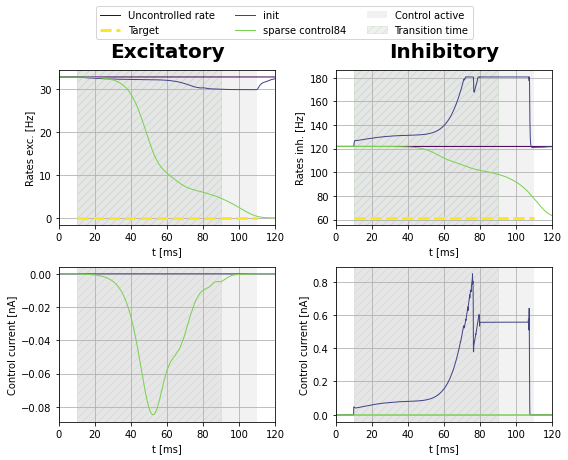

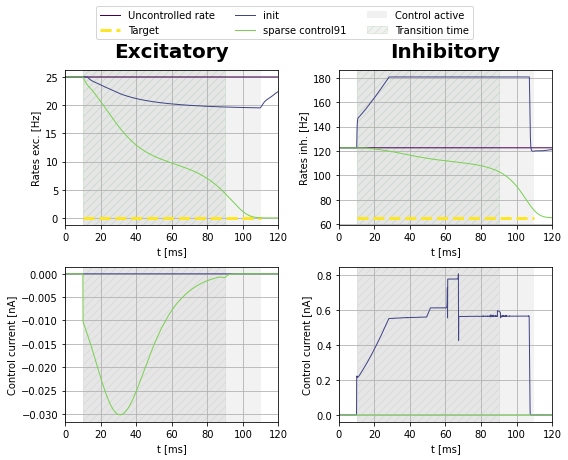

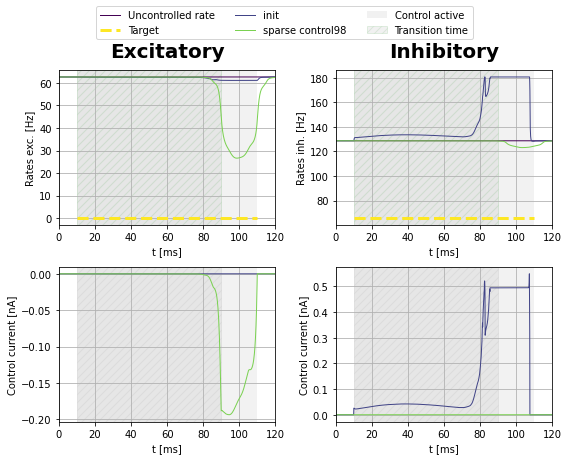

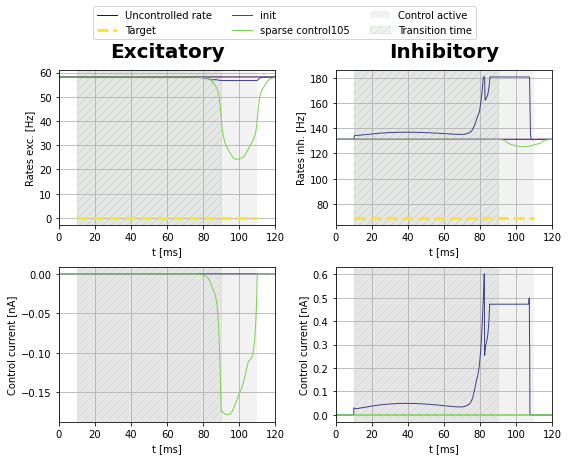

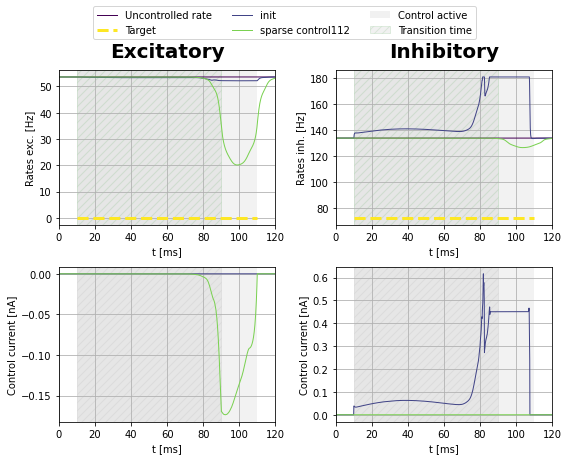

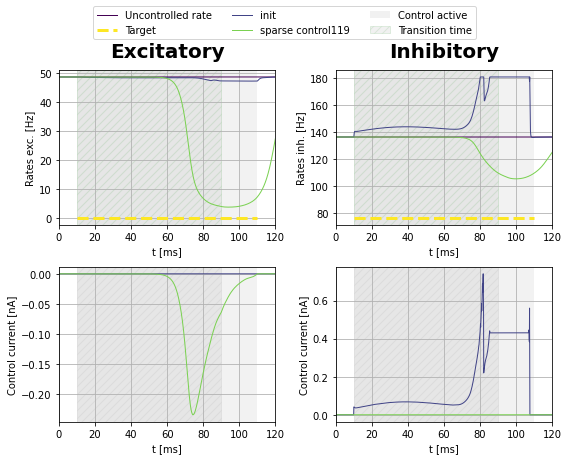

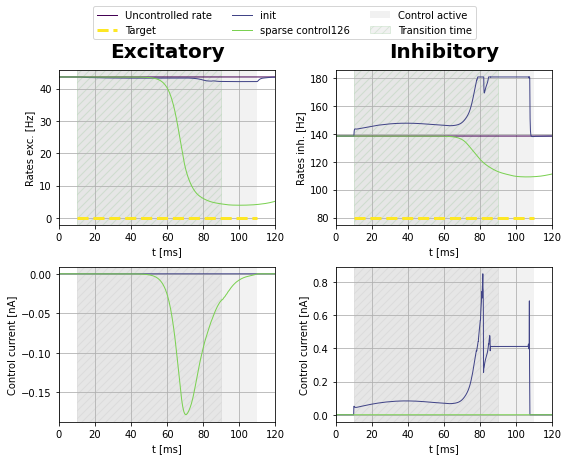

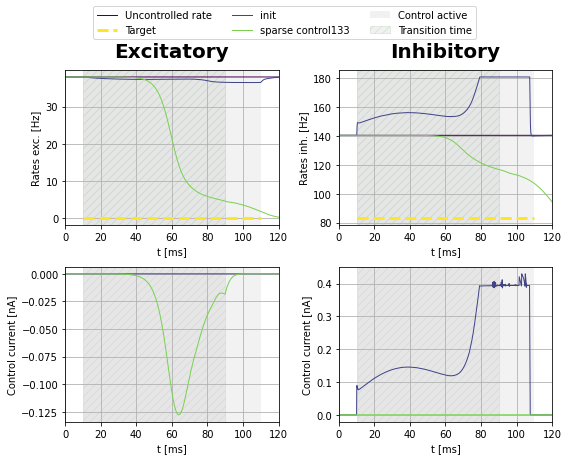

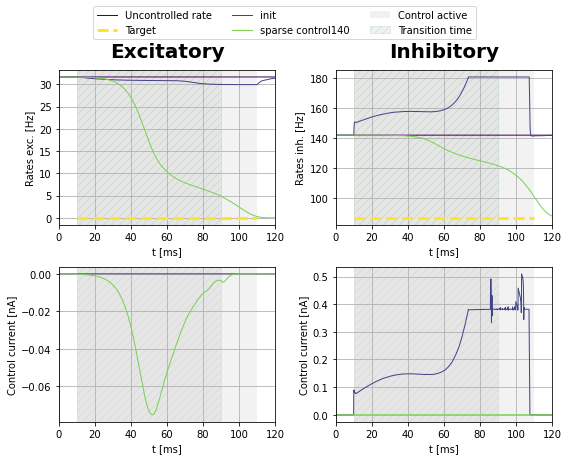

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6699.0055321967775
set cost params:  1.0 0.0 6699.0055321967775
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5900.288048512759
Gradient descend method:  None
RUN  1 , total integrated cost =  5900.2700526922445
RUN  2 , total integrated cost =  5900.26998942778
RUN  3 , total integrated cost =  5900.269989427769


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  5900.269989427769
Control only changes marginally.
RUN  4 , total integrated cost =  5900.269989427769
Improved over  4  iterations in  0.7085385248064995  seconds by  0.0003060712433153867  percent.
Problem in initial value trasfer:  Vmean_exc -62.29095666515238 -62.32492089789068
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  5636.245996606496
set cost params:  1.0 0.0 5636.245996606496
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13545.633784953354
Gradient descend method:  None
RUN  1 , total integrated cost =  13545.573674302452
RUN  2 , total integrated cost =  13545.571272090128
RUN  3 , total integrated cost =  13545.57115779344
RUN  4 , total integrated cost =  13545.571147042998
RUN  5 , total integrated cost =  13545.571145775353
RUN  6 , total integrated cost =  13545.571145652328
RUN  7 , total integrated cost =  13545.57114564039
RUN  8 , total integrated cost =  13545.571145639015
RU

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  13545.5711456388
Control only changes marginally.
RUN  12 , total integrated cost =  13545.5711456388
Improved over  12  iterations in  1.7590611893683672  seconds by  0.0004624317735704153  percent.
Problem in initial value trasfer:  Vmean_exc -58.11210065976263 -58.110881750300365
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  6207.851782028515
set cost params:  1.0 0.0 6207.851782028515
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8792.554814707146
Gradient descend method:  None
RUN  1 , total integrated cost =  8792.531981840119
RUN  2 , total integrated cost =  8792.531315699414
RUN  3 , total integrated cost =  8792.531297209121
RUN  4 , total integrated cost =  8792.531296773624
RUN  5 , total integrated cost =  8792.531296766834
RUN  6 , total integrated cost =  8792.53129676652
RUN  7 , total integrated cost =  8792.531296766498


...

RUN  3 , total integrated cost =  28711.34249036398
RUN  4 , total integrated cost =  28711.34249036398
Control only changes marginally.
RUN  4 , total integrated cost =  28711.34249036398
Improved over  4  iterations in  0.6920329481363297  seconds by  0.0002102829583776611  percent.
Problem in initial value trasfer:  Vmean_exc -56.703971613419455 -56.703983727802694
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 99
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.

ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  28711.362696940476
Control only changes marginally.
RUN  2 , total integrated cost =  28711.362696940476
Improved over  2  iterations in  0.42233931832015514  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.703971613419455 -56.703983727802694
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 100
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  28711.38236143831
Control only changes marginally.
RUN  1 , total integrated cost =  28711.38236143831
Improved over  1  iterations in  0.21460829116404057  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703971613419455 -56.703983727802694
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 101


In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  44.377427461385764
Gradient descend method:  None
RUN  1 , total integrated cost =  1.4624917027252633
RUN  2 , total integrated cost =  1.451547957328691
RUN  3 , total integrated cost =  1.4410609643482009
RUN  4 , total integrated cost =  1.439099565760294
RUN  5 , total integrated cost =  1.421049480581055
RUN  6 , total integrated cost =  1.4193775359072094
RUN  7 , total integrated cost =  1.419377535907204


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  1.4193775359072023
RUN  9 , total integrated cost =  1.4193775359072023
Control only changes marginally.
RUN  9 , total integrated cost =  1.4193775359072023
Improved over  9  iterations in  0.28951065987348557  seconds by  96.80157770041481  percent.
Problem in initial value trasfer:  Vmean_exc -63.84416137122734 -63.83454142447802
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  158.66983104172664
Gradient descend method:  None
RUN  1 , total integrated cost =  5.398029827288182
RUN  2 , total integrated cost =  5.376992338123717
RUN  3 , total integrated cost =  5.333953739260073
RUN  4 , total integrated cost =  5.332519033851427
RUN  5 , total integrated cost =  5.33251837725249
RUN  6 , total integrated cost =  5.332518352809419


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  5.332518352189818
RUN  8 , total integrated cost =  5.332518352165696
RUN  9 , total integrated cost =  5.3325183521650485
RUN  10 , total integrated cost =  5.332518352165043
RUN  11 , total integrated cost =  5.332518352165043
Control only changes marginally.
RUN  11 , total integrated cost =  5.332518352165043
Improved over  11  iterations in  0.28541626036167145  seconds by  96.63923613130797  percent.
Problem in initial value trasfer:  Vmean_exc -64.61106858230009 -64.60935716167553
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  69.43895513326243
Gradient descend method:  None
RUN  1 , total integrated cost =  2.434555075905023
RUN  2 , total integrated cost =  2.4295334333691634
RUN  3 , total integrated cost =  2.429522627785576
RUN  4 , total integrated cost =  2.4295224112325253
RUN  5 , total integrated cost =  2.429522411232516
RUN  6 , t

...

RUN  8 , total integrated cost =  16.540529126339564
RUN  9 , total integrated cost =  16.540529126339564
Control only changes marginally.
RUN  9 , total integrated cost =  16.540529126339564
Improved over  9  iterations in  0.27927782014012337  seconds by  90.62413290111145  percent.
Problem in initial value trasfer:  Vmean_exc -66.89633889787125 -66.93709896843893
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  124.68574316906864
Gradient descend method:  None
RUN  1 , total integrated cost =  9.962104091747854
RUN  2 , total integrated cost =  9.956423205074678
RUN  3 , total integrated cost =  9.948599378410531
RUN  4 , total integrated cost =  9.925748394737314


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  9.925748394737255
RUN  6 , total integrated cost =  9.925748394737251
RUN  7 , total integrated cost =  9.925748394737248
RUN  8 , total integrated cost =  9.925748394737248
Control only changes marginally.
RUN  8 , total integrated cost =  9.925748394737248
Improved over  8  iterations in  0.31674113497138023  seconds by  92.03938787028895  percent.
Problem in initial value trasfer:  Vmean_exc -69.14390969591143 -69.18811012272984
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81.84734075567658
Gradient descend method:  None
RUN  1 , total integrated cost =  5.010194285176786
RUN  2 , total integrated cost =  5.010152214045528
RUN  3 , total integrated cost =  5.010089729641834
RUN  4 , total integrated cost =  5.010035411751666
RUN  5 , total integrated cost =  5.008223090570205
RUN  6 , total integrated cost =  5.001734307768106
RUN  7 , total i

ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  5.001734307768103
Control only changes marginally.
RUN  8 , total integrated cost =  5.001734307768103
Improved over  8  iterations in  0.2624727711081505  seconds by  93.88894707929627  percent.
Problem in initial value trasfer:  Vmean_exc -71.67734722723273 -71.72219140346141


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.4193775359072023
Gradient descend method:  None
RUN  1 , total integrated cost =  1.4193775359072023
Control only changes marginally.
RUN  1 , total integrated cost =  1.4193775359072023
Improved over  1  iterations in  0.0632827952504158  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -63.84416137122734 -63.83454142447802
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.4295224112325076
Control only changes marginally.
RUN  1 , total integrated cost =  2.4295224112325076
Improved over  1  iterations in  0.06534038297832012  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -68.5707198394687 -68.58513635055566
-------  21 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8.465374180429205
Gradient descend method:  None
RUN  1 , total integrated cost =  8.465374180429205
Control only changes marginally.
RUN  1 , total integrated cost =  8.465374180429205
Improved over  1  iterations in  0.06447967141866684  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -66.02125915881214 -66.03531678607425
-------  28 0.5000000000000002 0.5000000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.560216673223

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  26428.956840952967
Control only changes marginally.
RUN  1 , total integrated cost =  26428.956840952967
Improved over  1  iterations in  0.0692103672772646  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703261500806406 -56.70332478528425
-------  119 0.5250000000000001 0.8250000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21.757944666663505
Gradient descend method:  None
RUN  1 , total integrated cost =  21.757944666663505
Control only changes marginally.
RUN  1 , total integrated cost =  21.757944666663505
Improved over  1  iterations in  0.06656563468277454  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -64.71117943636249 -64.7445027521926
-------  126 0.5000000000000002 0.8500000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16.54052912

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  9.925748394737248
Control only changes marginally.
RUN  1 , total integrated cost =  9.925748394737248
Improved over  1  iterations in  0.06606699526309967  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -69.14390969591143 -69.18811012272984
-------  140 0.4500000000000001 0.9000000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.001734307768103
Gradient descend method:  None
RUN  1 , total integrated cost =  5.001734307768103
Control only changes marginally.
RUN  1 , total integrated cost =  5.001734307768103
Improved over  1  iterations in  0.06644179113209248  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -71.67734722723273 -71.72219140346141
--------------- 21
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [Fa

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4.269654315475669
Improved over  1  iterations in  0.06499687395989895  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -71.19739866057895 -71.23656928355324
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
converged for  98
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 22
[[True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [False, False], [True, False

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
